# AI for Finance
##  Hands-on Practice on Financial AI Session #3-1

In [1]:
# Pandas and numpy for data manipulation
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score,f1_score

# Classification Model Using XGBClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings(action='ignore')

In [2]:
# Setting Seed for Score Assignments
import random
SEED = 14
np.random.seed(SEED)
random.seed(SEED)

In [3]:
df = pd.read_csv('S3_1_data.csv', encoding = 'utf-8-sig', index_col = 0)

nan_idx = df.loc[pd.isna(df).any(axis=1), :].index
df_original_test = np.log(df.fillna(method='ffill', inplace=False)) - np.log(df.fillna(method='ffill', inplace=False).shift(1))
df_original_test.loc[nan_idx, :] = np.nan
df_original_test.dropna(inplace=True, axis=0)

df_original = df_original_test.copy()

# Making Source Variables
X_df = df_original.drop(['Republic of Korea (KOSPI)'], axis = 1)

# Making Target Variable (KOSPI)
y_df = pd.DataFrame()
y_df_temp = pd.DataFrame(df_original['Republic of Korea (KOSPI)'])
y_df['target'] = [1 if s > 0 else 0 for s in y_df_temp['Republic of Korea (KOSPI)']]
y_df.index = X_df.index
y_df = y_df.shift(-1)
y_df = y_df.dropna()
X_df = X_df.iloc[:-1, :]

## 1. [File: 3-1] Please include the last five data columns and rows of the ‘df_original’ dataset

In [4]:
# last 5 columns
df_original.tail().iloc[:, -5:]

,Indonesia (Jakarta Composite Index),EU (Eurostoxx 50),Gold-USD,Bitcoin-USD,WTI-USD
date,,,,,
2021-11-18,-0.005909,-0.003895,-0.004563,-0.058189,0.008261
2021-11-22,0.000466,-0.004090,-0.021680,-0.041832,0.008505
2021-11-24,0.000808,-0.001769,-0.000687,-0.006998,-0.001402
2021-11-26,-0.020784,-0.048599,0.001877,-0.092449,-0.127405
2021-11-29,0.007098,0.004862,-0.003802,0.008747,0.026070


In [5]:
# Making Training Sets and Test Sets
threshold_date = "2021-01-01"

X_train = X_df[X_df.index < threshold_date]
X_test = X_df[X_df.index >= threshold_date]
y_train = y_df[y_df.index < threshold_date]
y_test = y_df[y_df.index >= threshold_date]

In [6]:
# Training Defulat XGBClassifier Models
model = XGBClassifier(random_state = SEED)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=14, ...)

In [7]:
# Conducting Test and Classification Results
y_pred = pd.DataFrame(model.predict(X_test))
y_score = pd.DataFrame(model.predict_proba(X_test)).round(4)

print(y_test)

y_pred.index = y_test.index
y_score.index = y_test.index
y_result = pd.concat([y_test, y_pred, y_score], axis = 1)

y_result.columns = ['Test Data (Original)', 'Prediction Results', 'Probability of Predicting Bearish Market', 'Probability of Predicting Bullish Market']
y_result.to_csv('classification_results.csv', encoding = 'utf-8-sig')

            target
date              
2021-01-04     1.0
2021-01-05     0.0
2021-01-06     1.0
2021-01-08     0.0
2021-01-12     1.0
...            ...
2021-11-17     0.0
2021-11-18     1.0
2021-11-22     0.0
2021-11-24     0.0
2021-11-26     0.0

[129 rows x 1 columns]


## 2. [File: 3-1] Please write the max value of columns ‘Probability of Predicting Bullish Market’ and ‘Probability of Predicting Bearish Market’ in the dataframe ‘y_result’

In [8]:
# Load the newly uploaded classification_results.csv file
classification_results = pd.read_csv("/content/classification_results.csv")

# Calculate the maximum values for the required columns
max_bullish = classification_results["Probability of Predicting Bullish Market"].max()
max_bearish = classification_results["Probability of Predicting Bearish Market"].max()

print("Max value of the column ‘Probability of Predicting Bullish Market': ", max_bullish)
print("Max value of the column ‘Probability of Predicting Bearish Market’: ", max_bearish)

Max value of the column ‘Probability of Predicting Bullish Market':  0.9982
Max value of the column ‘Probability of Predicting Bearish Market’:  0.9913


## 3. [File: 3-1] Please attach the ‘classification_results.csv’ file

In [10]:
classification_results.head()

,date,Test Data (Original),Prediction Results,Probability of Predicting Bearish Market,Probability of Predicting Bullish Market
0,2021-01-04,1.0,1,0.1823,0.8177
1,2021-01-05,0.0,1,0.2514,0.7486
2,2021-01-06,1.0,1,0.1456,0.8544
3,2021-01-08,0.0,1,0.0281,0.9719
4,2021-01-12,1.0,1,0.0967,0.9033


## 4. [File: 3-1] Please attach the ‘confusion_matrix.png’ file

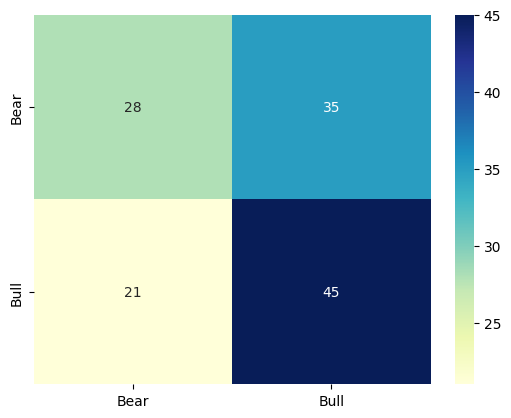

In [11]:
# Performance Evaluation
cf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cf_matrix, annot=True, xticklabels = ['Bear', 'Bull'], yticklabels = ['Bear', 'Bull'], cmap="YlGnBu")
plt.savefig('confusion_matrix.png')

Confusion Matrix 구성:

실제 Bear → 예측 Bear: 28

실제 Bear → 예측 Bull: 35

실제 Bull → 예측 Bear: 21

실제 Bull → 예측 Bull: 45

## 5. [File: 3-1] Write the accuracy and F1 score derived from the test. (2 pts)

In [12]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy is " + str(round(accuracy*100, 2)) + "%")
print("F1 Score is " + str(round(f1*100, 2)) + "%")

Accuracy is 56.59%
F1 Score is 61.64%
